<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Indep_t_test_golf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study
Par Inc., is a major manufacturer of golf equipment. Management believes that Par’s market share could be increased with the introduction of a cut-resistant, longer-lasting golf ball. Therefore, the research group at Par has been investigating a new golf ball coating designed to resist cuts and provide a more durable ball. The tests with the coating have been promising. One of the researchers voiced concern about the effect of the new coating on driving distances. Par would like the new cut-resistant ball to offer driving distances comparable to those of the current-model golf ball. To compare the driving distances for the two balls, 40 balls of both the new and current models were subjected to distance tests. The testing was performed with a mechanical hitting machine so that any difference between the mean distances for the two models could be attributed to a difference in the design.
Formulate and present the rationale for a hypothesis test that par
could use to conclude that the average driving distances of the new
golf balls is more than current.  [Data: golf.csv]





# Import necessary packages

In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Mounting Google drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Read data

In [5]:
# Reading the data

df = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/Golf.xlsx')

# Exploratory Analysis

In [6]:
df.columns

Index(['Current', 'New'], dtype='object')

In [7]:
df.head()                                   # Viewing first few observations of the data

,Current,New
0,264,277
1,261,269
2,267,263
3,272,266
4,258,262


In [8]:
df.describe()                               # Descriptive statistics

,Current,New
count,40.000000,40.000000
mean,270.275000,267.500000
std,8.752985,9.896904
min,255.000000,250.000000
25%,263.000000,262.000000
50%,270.000000,265.000000
75%,275.250000,274.500000
max,289.000000,289.000000


<Axes: >

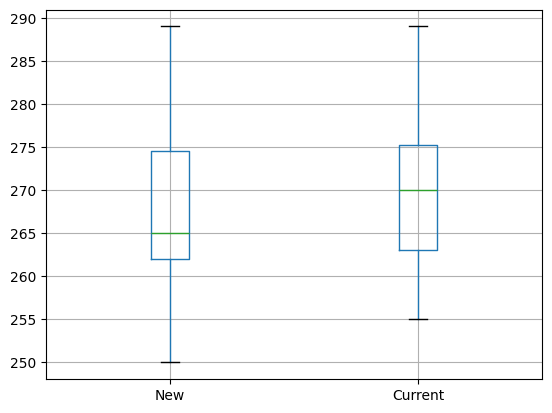

In [12]:
df.boxplot(column=['New', 'Current']) # Box plot

# Normality test using Shapiro test

In [13]:
Shapiro1 = stats.shapiro(df.New)

print("Shapiro-Wilk test for New:", Shapiro1)

Shapiro-Wilk test for New: ShapiroResult(statistic=np.float64(0.9678264239239943), pvalue=np.float64(0.3064663136508391))


In [14]:
Shapiro2 = stats.shapiro(df.Current)

print("Shapiro-Wilk test for Current:", Shapiro2)

Shapiro-Wilk test for Current: ShapiroResult(statistic=np.float64(0.9707050133002175), pvalue=np.float64(0.3787958248926949))


# Normality check using Q-Q plot

In [15]:
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

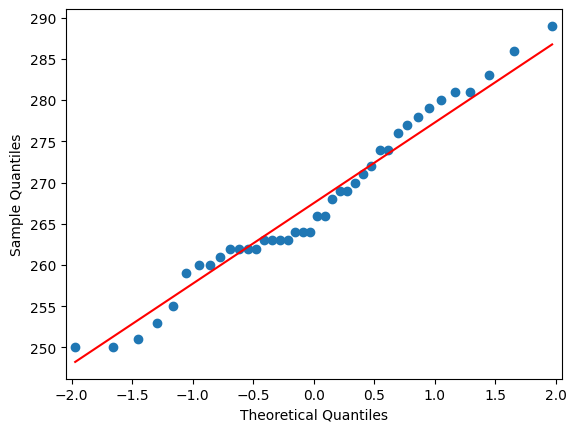

In [16]:
qqplot(df['New'], line='s')
plt.show()

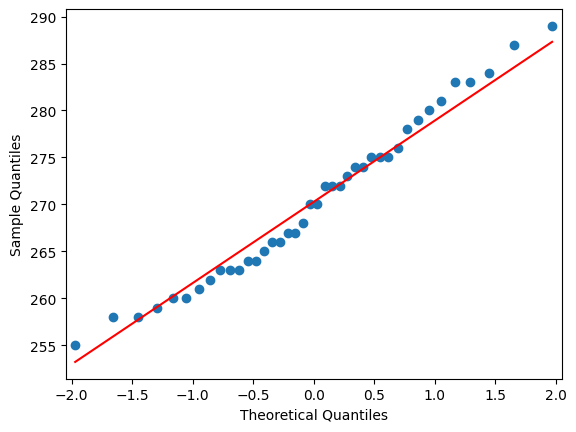

In [17]:
qqplot(df['Current'], line='s')
plt.show()


## Testing Equality of Variances

In [18]:
# Levene test using Center as Mean
stats.levene(df['New'], df['Current'],center='mean')

LeveneResult(statistic=np.float64(0.4454881721113651), pvalue=np.float64(0.5064553165908879))

# Independent t test

In [19]:
res = stats.ttest_ind(df['New'], df['Current'],equal_var=True,
  alternative='greater')
res

TtestResult(statistic=np.float64(-1.3283615935245678), pvalue=np.float64(0.9060338575407267), df=np.float64(78.0))

In [20]:
print("Average performance of New:",(df['New']).mean())
print("Average performance of Current:",(df['Current']).mean())

Average performance of New: 267.5
Average performance of Current: 270.275
